## 1 PROBLEM STATEMENT

Air pollution poses significant health and environmental risks. Accurate forecasting of air quality indicators such as CO, NO₂, and PM levels can help authorities take preventive measures. This project aims to analyze historical air quality data and develop time series models to predict future pollution levels.

### 2 Loading and Exploring Data

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#the main lib here is the statmodel
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA


In [33]:
df = pd.read_csv(r"C:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\AirQualityUCI.csv")

In [34]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), str(2)
memory usage: 1.2 MB


In [36]:
# Drop empty columns
df.drop(columns=['Unnamed: 15', 'Unnamed: 16'], inplace=True)

In [37]:
# Drop rows where Date is missing
df.dropna(subset=['Date'], inplace=True)

In [38]:
# Reset index
df.reset_index(drop=True, inplace=True)

In [39]:
print(df.shape)

(9357, 15)


In [40]:
print(df.isnull().sum())

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [41]:
# convert Date and Time to datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

In [42]:
df.set_index('Datetime', inplace=True)


In [43]:
df.drop(columns=['Date', 'Time'], inplace=True)

In [44]:
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [45]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         9357 non-null   float64
 1   PT08.S1(CO)    9357 non-null   float64
 2   NMHC(GT)       9357 non-null   float64
 3   C6H6(GT)       9357 non-null   float64
 4   PT08.S2(NMHC)  9357 non-null   float64
 5   NOx(GT)        9357 non-null   float64
 6   PT08.S3(NOx)   9357 non-null   float64
 7   NO2(GT)        9357 non-null   float64
 8   PT08.S4(NO2)   9357 non-null   float64
 9   PT08.S5(O3)    9357 non-null   float64
 10  T              9357 non-null   float64
 11  RH             9357 non-null   float64
 12  AH             9357 non-null   float64
dtypes: float64(13)
memory usage: 1023.4 KB


#### Handling Hidden Missing values

The dataset stores missing values as -200.So next we need to replace those hidden missing values properly.

In [46]:
# handling hidden missing values
df.replace(-200, np.nan, inplace=True)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314.0,NaN,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
2005-04-04 11:00:00,2.4,1163.0,NaN,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
2005-04-04 12:00:00,2.4,1142.0,NaN,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406


In [47]:
# check missing values
df.isnull().sum().sort_values(ascending=False)

NMHC(GT)         8443
CO(GT)           1683
NO2(GT)          1642
NOx(GT)          1639
PT08.S1(CO)       366
PT08.S2(NMHC)     366
C6H6(GT)          366
PT08.S3(NOx)      366
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

NMHC(GT),is missing almost 90%,8443 missing out of 9357,which means it is almost unusable,so I decided to drop it

In [48]:
df.drop(columns=['NMHC(GT)'], inplace=True)

The major pollutants CO(GT),NO2(GT),NOx(GT) have a missingness of around 18%.They are important so they shall be retained.The other variables have a missingness of 366,here we shall impute

In [49]:
# interpolate missing values
df.interpolate(method='time', inplace=True)

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
2005-04-04 11:00:00,2.4,1163.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
2005-04-04 12:00:00,2.4,1142.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406


In [50]:
df = df.bfill().ffill()

In [51]:
df.isnull().sum()

CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

array([<Axes: xlabel='Datetime'>, <Axes: xlabel='Datetime'>,
       <Axes: xlabel='Datetime'>, <Axes: xlabel='Datetime'>,
       <Axes: xlabel='Datetime'>, <Axes: xlabel='Datetime'>,
       <Axes: xlabel='Datetime'>, <Axes: xlabel='Datetime'>,
       <Axes: xlabel='Datetime'>, <Axes: xlabel='Datetime'>,
       <Axes: xlabel='Datetime'>, <Axes: xlabel='Datetime'>], dtype=object)

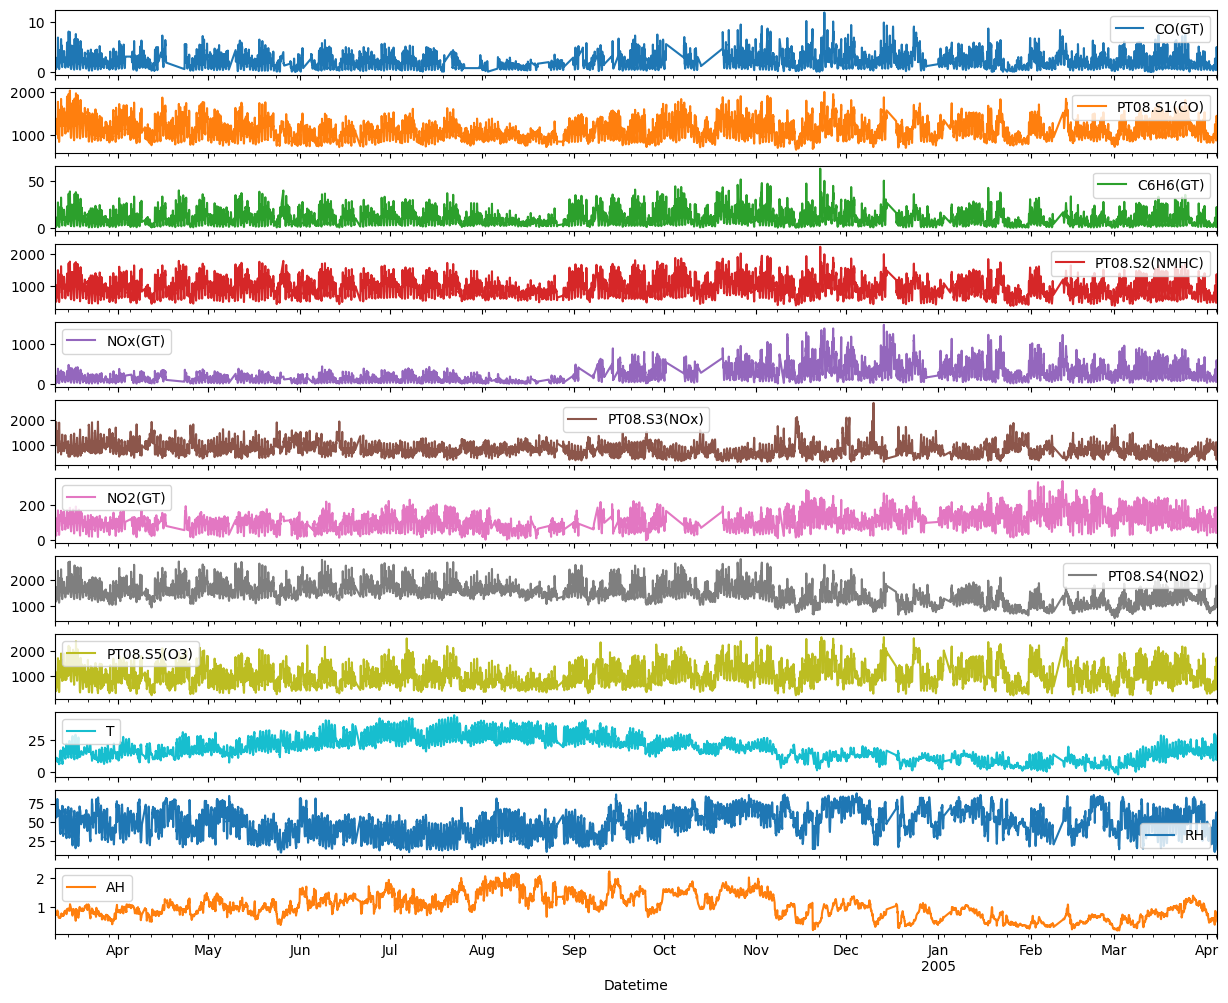

In [52]:
df.describe()
df.plot(subplots=True, figsize=(15, 12))

Target variable chose is 'C0(GT)'

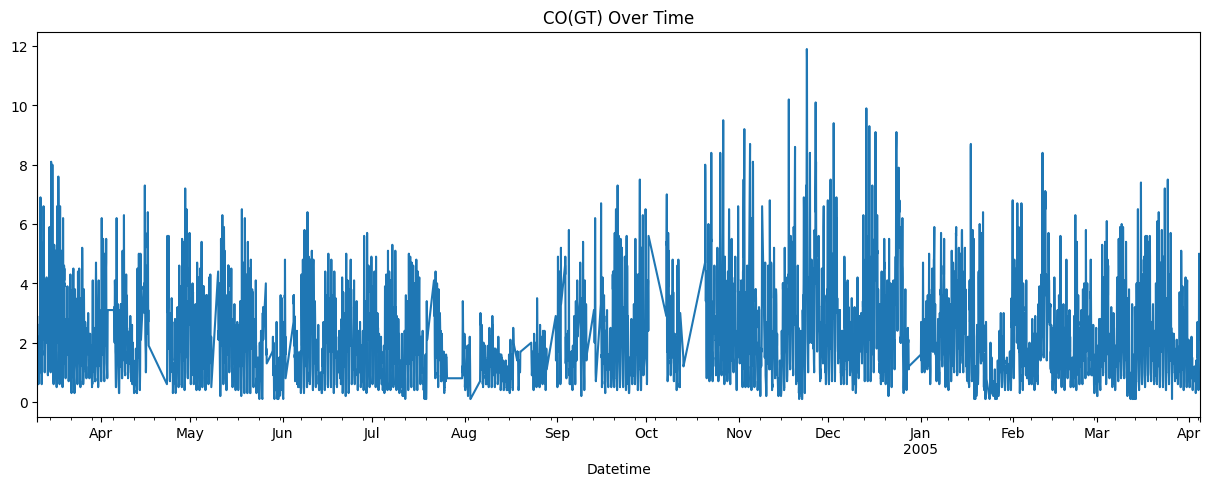

In [53]:
df['CO(GT)'].plot(figsize=(15,5), title='CO(GT) Over Time')
plt.show()

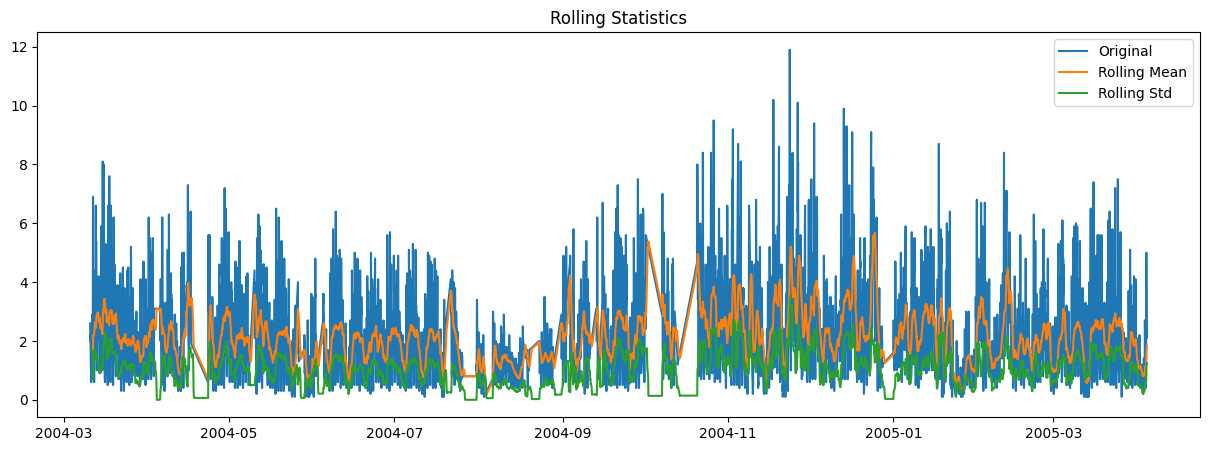

In [54]:
rolling_mean = df['CO(GT)'].rolling(window=24).mean()
rolling_std = df['CO(GT)'].rolling(window=24).std()

plt.figure(figsize=(15,5))
plt.plot(df['CO(GT)'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title('Rolling Statistics')
plt.show()

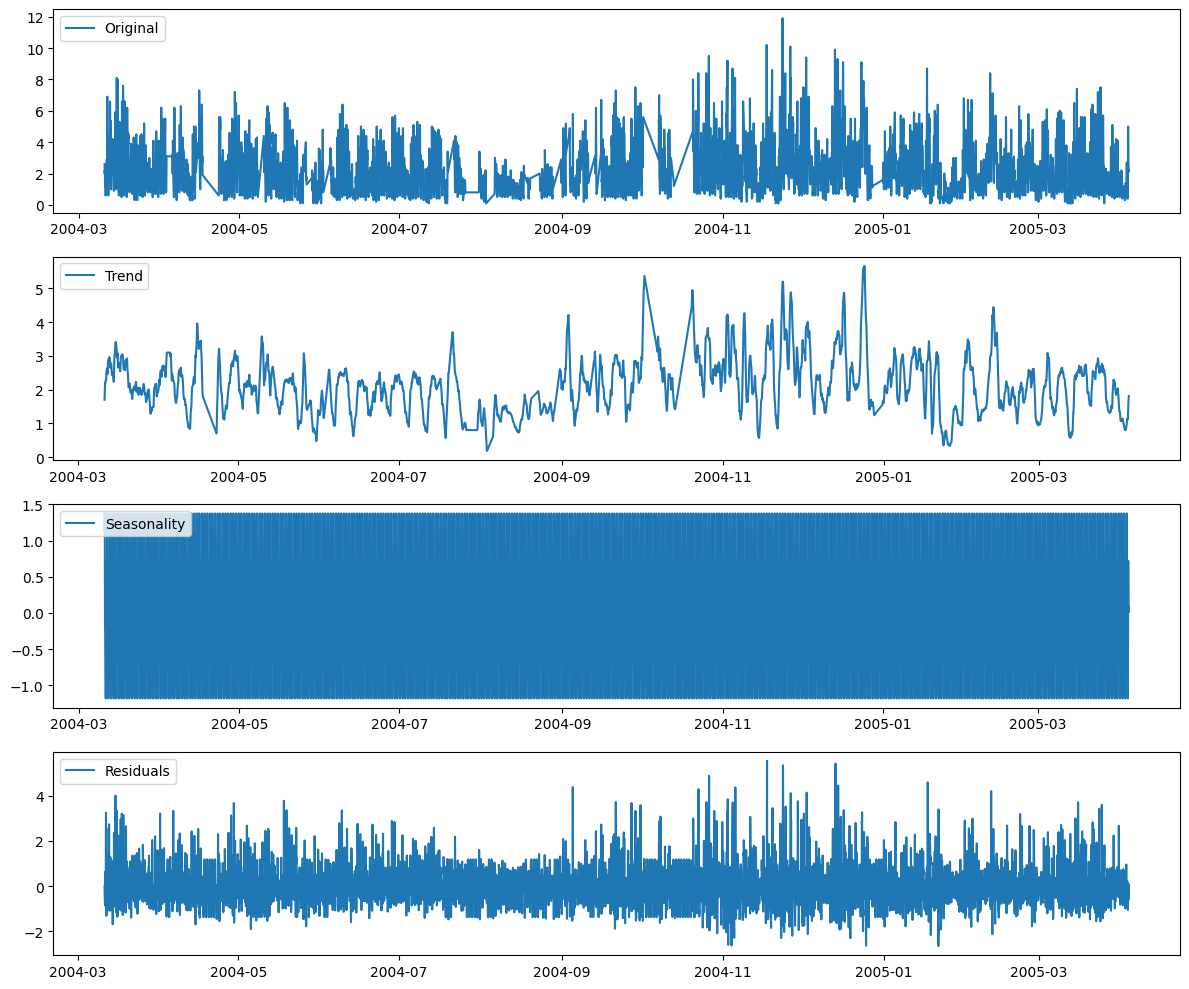

In [55]:
result = seasonal_decompose(
    df['CO(GT)'],
    model='additive',   # usually better for pollutant data
    period=24           # hourly data → daily seasonality
)
plt.figure(figsize=(12, 10))
plt.subplot(411)
plt.plot(df['CO(GT)'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal, label='Seasonality')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid, label='Residuals')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Insights From Time Series Decomposition

-  The time series has a trend,though a week one due to the fluctuations over time
-  There's clearly daily seasonality
-  The time series exhibits both trend and strong daily seasonality, indicating that it is non-stationary

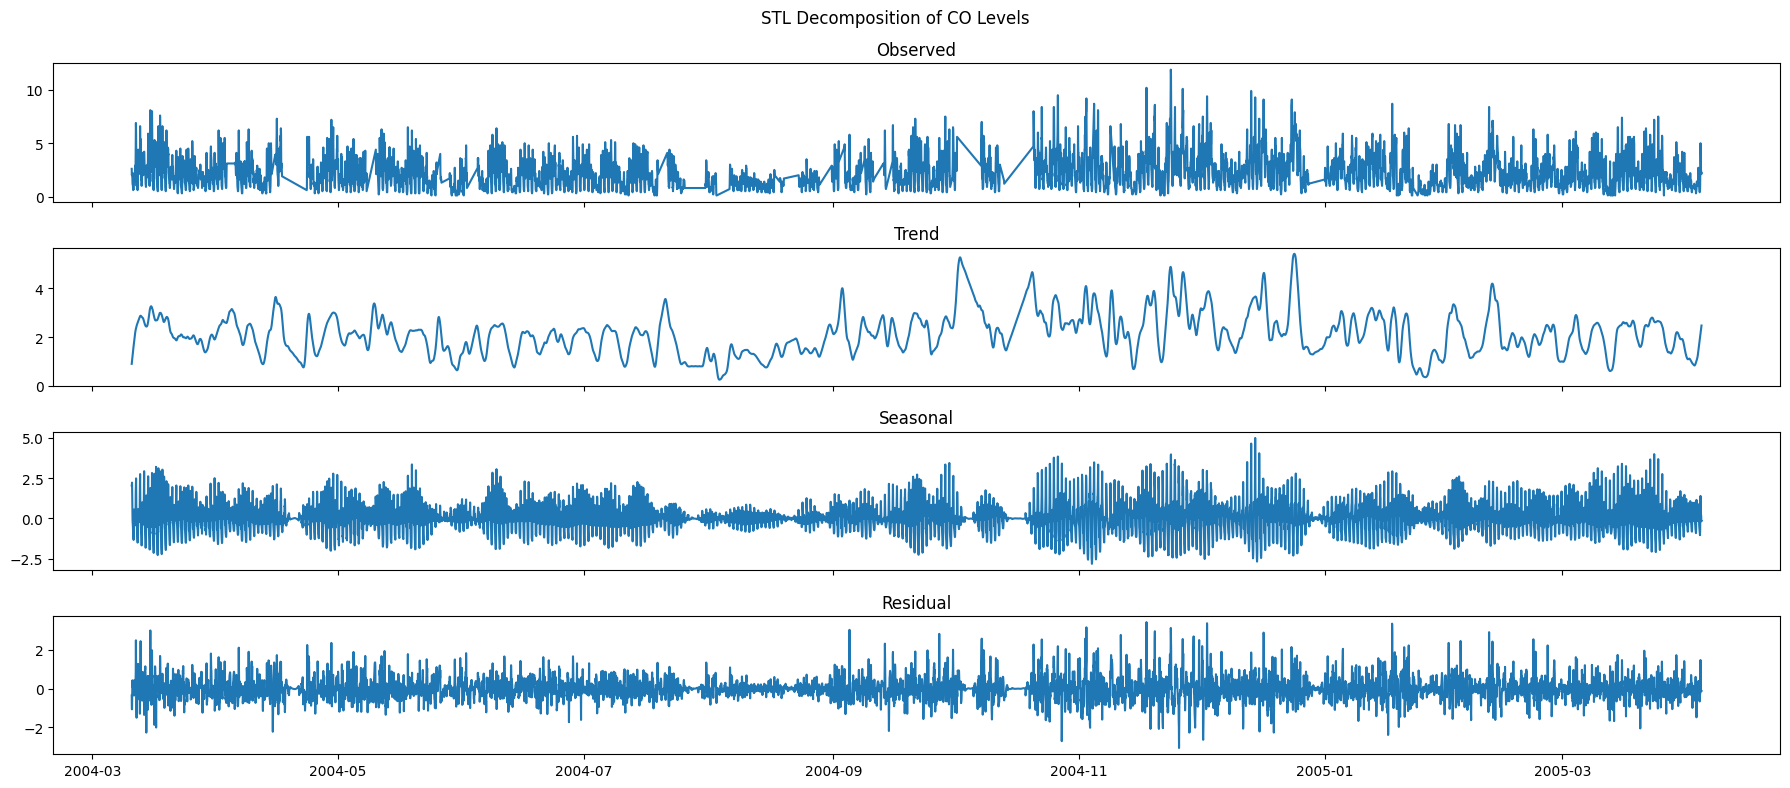

In [56]:

# Apply STL decomposition
stl = STL(df['CO(GT)'], period=24)
result = stl.fit()

# Plot
fig, axs = plt.subplots(4, 1, figsize=(18, 8), sharex=True)

axs[0].plot(result.observed)
axs[0].set_title('Observed')

axs[1].plot(result.trend)
axs[1].set_title('Trend')

axs[2].plot(result.seasonal)
axs[2].set_title('Seasonal')

axs[3].plot(result.resid)
axs[3].set_title('Residual')

plt.suptitle('STL Decomposition of CO Levels')
plt.tight_layout()
plt.show()

The STL decomposition reveals the presence of a time-varying trend and strong seasonal patterns. This suggests that the series contains deterministic structures that should be explicitly modeled, particularly using seasonal models such as SARIMA.

### Stationarity Testing

In [57]:
result = adfuller(df['CO(GT)'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

# Decision based on p-value
if result[1] <= 0.05:
    print("Reject the null hypothesis (H0). The time series is stationary.")
else:
    print("The p values is more than 0.05,Fail to reject the null hypothesis (H0). The time series is non-stationary.")

ADF Statistic: -9.872734502489505
p-value: 3.955249156436486e-17
Critical Values:
	1%: -3.431051910310215
	5%: -2.8618502001074853
	10%: -2.566935114435797
Reject the null hypothesis (H0). The time series is stationary.


The Augmented Dickey-Fuller test returned an ADF statistic of -9.87 with a p-value effectively equal to zero. Since the p-value is below 0.05 and the test statistic is more negative than all critical values, we reject the null hypothesis of a unit root and conclude that the CO(GT) time series is stationary

## 3 Data Preprocessing

### Auto-Correlation

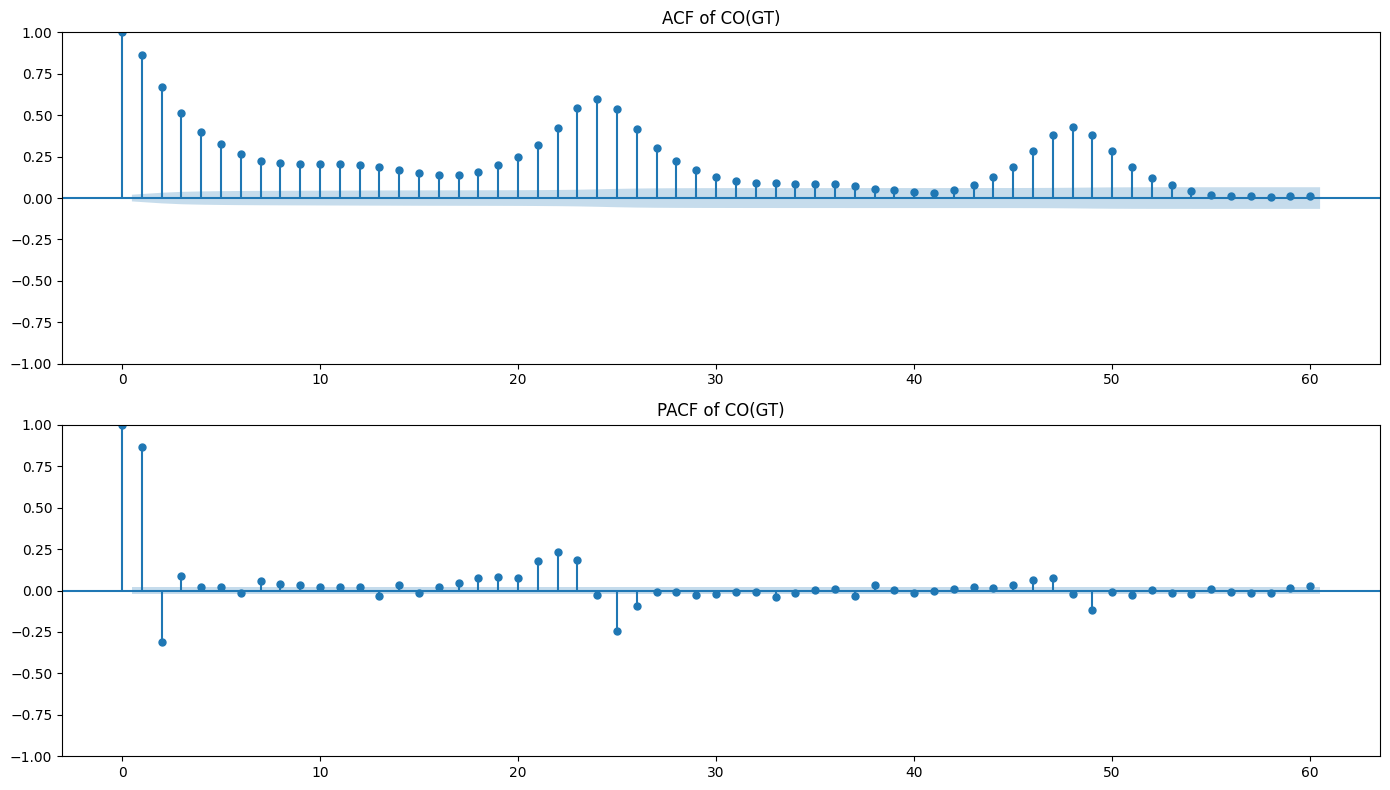

In [58]:
series = df['CO(GT)'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(series, lags=60, ax=axes[0])
axes[0].set_title('ACF of CO(GT)')

plot_pacf(series, lags=60, ax=axes[1], method='ywm')
axes[1].set_title('PACF of CO(GT)')

plt.tight_layout()
plt.show()

### Insights from ACF and PACF plots

## 4 Modeling

Train Test Split

In [59]:

split_point = int(len(df['CO(GT)']) * 0.8)

train = df['CO(GT)'].iloc[:split_point]
test = df['CO(GT)'].iloc[split_point:]

print(f"Total data points: {len(df['CO(GT)'])}")
print(f"Training data points: {len(train)}")
print(f"Testing data points: {len(test)}")

Total data points: 9357
Training data points: 7485
Testing data points: 1872


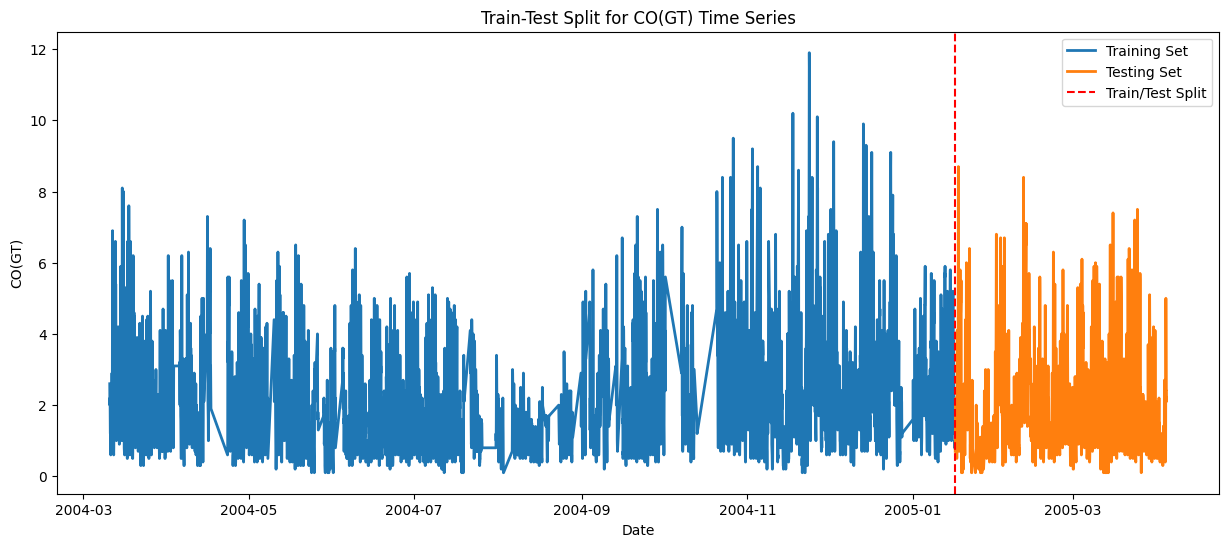

In [60]:
plt.figure(figsize=(15,6))

plt.plot(train, label='Training Set', linewidth=2)
plt.plot(test, label='Testing Set', linewidth=2)

plt.axvline(
    x=test.index[0],
    color='red',
    linestyle='--',
    label='Train/Test Split'
)

plt.title('Train-Test Split for CO(GT) Time Series')
plt.xlabel('Date')
plt.ylabel('CO(GT)')
plt.legend()
plt.show()

In [61]:
# fit the models
arima_model = ARIMA(train, order=(1,0,1))
arima_results = arima_model.fit()

print(arima_results.summary())

c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\advanced\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\advanced\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\advanced\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 CO(GT)   No. Observations:                 7485
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -7694.171
Date:                Sat, 02 May 2026   AIC                          15396.342
Time:                        10:36:58   BIC                          15424.025
Sample:                    03-10-2004   HQIC                         15405.849
                         - 01-16-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1895      0.068     32.297      0.000       2.057       2.322
ar.L1          0.7952      0.006    132.142      0.000       0.783       0.807
ma.L1          0.3422      0.008     41.192      0.0

#### Forecast the Arima test horizon

In [69]:
arima_forecast_obj = arima_results.get_forecast(steps=len(test))

arima_pred = arima_forecast_obj.predicted_mean

In [70]:
arima_mae = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))

print(f"ARIMA MAE: {arima_mae:.2f}")
print(f"ARIMA RMSE: {arima_rmse:.2f}")

ARIMA MAE: 1.14
ARIMA RMSE: 1.41


In [62]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,24)
)

sarima_results = sarima_model.fit()

print(sarima_results.summary())

c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\advanced\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\advanced\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                             CO(GT)   No. Observations:                 7485
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood               -6542.760
Date:                            Sat, 02 May 2026   AIC                          13095.520
Time:                                    10:37:47   BIC                          13130.107
Sample:                                03-10-2004   HQIC                         13107.400
                                     - 01-16-2005                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8034      0.006    135.197      0.000       0.792       0.815
ma.L1          0.1730      0.009   

### Manual Model Tuning

In [63]:
models = [
    ((1,0,1),(1,1,1,24)),
    ((2,0,1),(1,1,1,24)),
    ((1,0,2),(1,1,1,24)),
    ((1,0,1),(2,1,1,24))
]

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
results_list = []

for order, seasonal_order in models:
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order
        )

        fitted = model.fit(disp=False)

        forecast = fitted.forecast(steps=len(test))

        mae = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mean_squared_error(test, forecast))

        results_list.append({
            'Order': order,
            'Seasonal Order': seasonal_order,
            'AIC': fitted.aic,
            'MAE': mae,
            'RMSE': rmse
        })

    except Exception as e:
        print(f"Model {order} {seasonal_order} failed: {e}")

comparison_df = pd.DataFrame(results_list)
comparison_df = comparison_df.sort_values('RMSE')

print(comparison_df)

c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\advanced\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\advanced\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\advanced\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\advanced\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init

       Order Seasonal Order           AIC       MAE      RMSE
2  (1, 0, 2)  (1, 1, 1, 24)  13074.685654  1.049700  1.289915
1  (2, 0, 1)  (1, 1, 1, 24)  13081.453138  1.051355  1.291127
0  (1, 0, 1)  (1, 1, 1, 24)  13095.519520  1.053021  1.292442
3  (1, 0, 1)  (2, 1, 1, 24)  13096.558823  1.054655  1.294149


Due to computational constraints associated with exhaustive seasonal auto_arima search on high-frequency hourly data, SARIMA hyperparameters were refined through targeted manual experimentation informed by STL decomposition and model diagnostics.

In [71]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA'],
    'MAE': [arima_mae, mae],
    'RMSE': [arima_rmse, rmse]
})

print(comparison)

    Model       MAE      RMSE
0   ARIMA  1.143888  1.411044
1  SARIMA  1.054655  1.294149


The SARIMA model outperformed the baseline ARIMA model across all forecast accuracy metrics, reducing MAE from 1.144 to 1.055 and RMSE from 1.411 to 1.294. This improvement indicates that incorporating seasonal components enhanced the model’s ability to capture recurring temporal patterns in CO concentration levels.

### Residual Diagnosis

In [73]:
# refit the best SARIMA model
best_sarima = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,24)
)

best_sarima_results = best_sarima.fit(disp=False)

c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\advanced\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING_CAPSTONE\advanced\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [74]:
forecast_obj = best_sarima_results.get_forecast(steps=len(test))

best_forecast = forecast_obj.predicted_mean

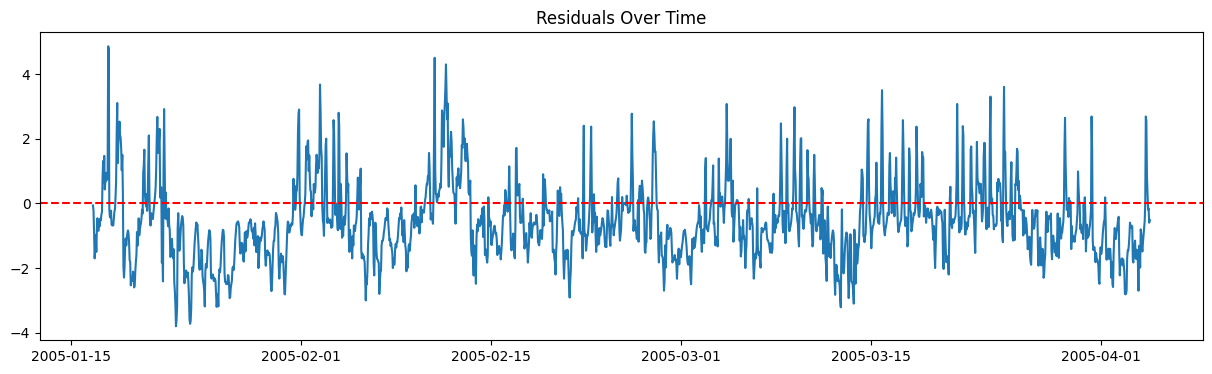

In [75]:
# Residuals time plot
residuals = test - best_forecast

plt.figure(figsize=(15,4))
plt.plot(residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Over Time')
plt.show()

## 5.Forecasting and model evaluation

In [76]:
n_steps = len(test)

forecast_obj = fitted.get_forecast(steps=n_steps)

# Predicted values + confidence intervals
y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# Convert to aligned Series for plotting
fc_series = pd.Series(y_pred.values, index=test.index)
lower_series = pd.Series(conf_int.iloc[:, 0].values, index=test.index)
upper_series = pd.Series(conf_int.iloc[:, 1].values, index=test.index)

In [77]:
fc_series

Datetime
2005-01-16 15:00:00    0.760804
2005-01-16 16:00:00    1.322034
2005-01-16 17:00:00    2.015024
2005-01-16 18:00:00    2.929302
2005-01-16 19:00:00    3.436512
                         ...   
2005-04-04 10:00:00    2.746576
2005-04-04 11:00:00    2.600917
2005-04-04 12:00:00    2.555521
2005-04-04 13:00:00    2.703222
2005-04-04 14:00:00    2.724341
Length: 1872, dtype: float64

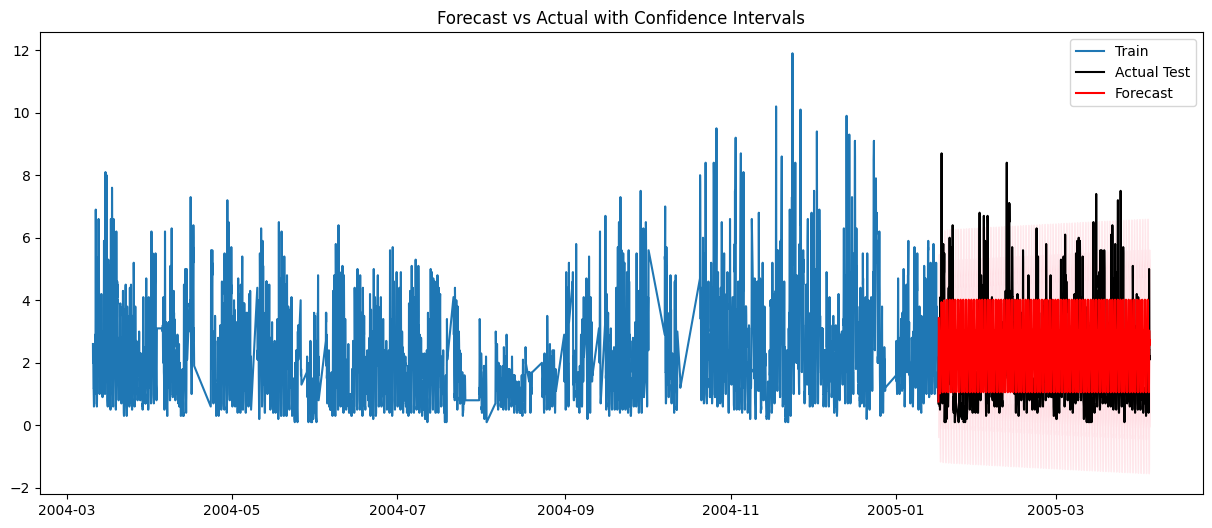

In [78]:
plt.figure(figsize=(15,6))

plt.plot(train, label='Train')
plt.plot(test, label='Actual Test', color='black')
plt.plot(fc_series, label='Forecast', color='red')

plt.fill_between(
    lower_series.index,
    lower_series,
    upper_series,
    color='pink',
    alpha=0.3
)

plt.legend()
plt.title('Forecast vs Actual with Confidence Intervals')
plt.show()

## Evaluate Model Performance

In [79]:
mae = mean_absolute_error(test, y_pred)
rmse = np.sqrt(mean_squared_error(test, y_pred))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 1.05
RMSE: 1.29


In [80]:
mae = mean_absolute_error(test, fc_series)
rmse = np.sqrt(mean_squared_error(test, fc_series))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.0546551322609747
RMSE: 1.2941487197468475
